# Football Player Position Prediction - Model Training

Notebook ini berisi proses training model untuk prediksi posisi pemain sepak bola.

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Load Data dengan Embeddings

In [2]:
# Load data dari CSV yang sudah ada embeddings
csv_path = "../data/player_embeddings.csv"

print(f"📂 Loading data from: {csv_path}")
df = pd.read_csv(csv_path)

print(f"✅ Loaded {len(df)} players")
print(f"\n📊 Dataset shape: {df.shape}")
print(f"\n📋 Columns:")
print(df.columns.tolist())

📂 Loading data from: ../data/player_embeddings.csv
✅ Loaded 3993 players

📊 Dataset shape: (3993, 12)

📋 Columns:
['full_name', 'age', 'positions', 'primary_position', 'acceleration', 'sprint_speed', 'dribbling', 'short_passing', 'finishing', 'stamina', 'strength', 'embedding']


In [3]:
# Parse embedding dari JSON string
df['embedding'] = df['embedding'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

# Parse primary position
df['primary_position'] = df['positions'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)

print("✅ Embeddings parsed successfully")
print(f"\n📊 Embedding dimension: {len(df['embedding'].iloc[0])}D")
print(f"\n🎯 Unique positions: {df['primary_position'].nunique()}")

✅ Embeddings parsed successfully

📊 Embedding dimension: 64D

🎯 Unique positions: 15

🎯 Unique positions: 15


## 📊 Exploratory Data Analysis

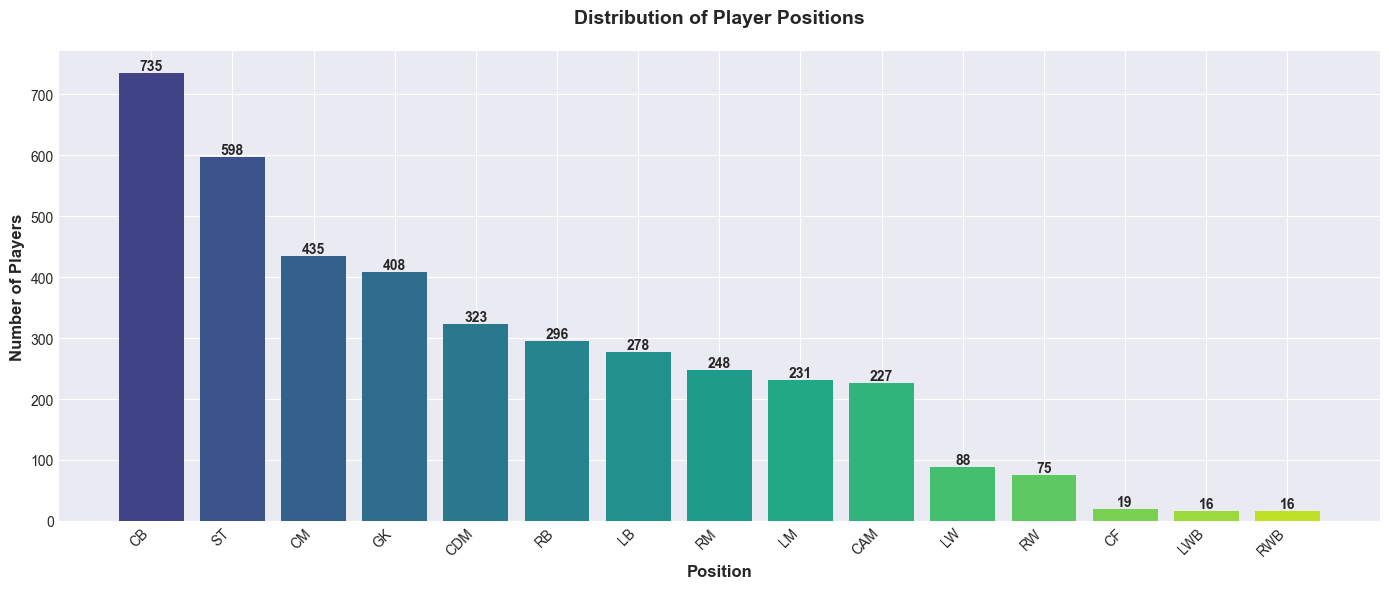


📊 Position Distribution:
primary_position
CB     735
ST     598
CM     435
GK     408
CDM    323
RB     296
LB     278
RM     248
LM     231
CAM    227
LW      88
RW      75
CF      19
LWB     16
RWB     16
Name: count, dtype: int64


In [4]:
# Position distribution
fig, ax = plt.subplots(figsize=(14, 6))

position_counts = df['primary_position'].value_counts()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(position_counts)))

bars = ax.bar(position_counts.index, position_counts.values, color=colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Players', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Player Positions', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 Position Distribution:")
print(position_counts)

In [5]:
# Sample data
print("\n👤 Sample Players:")
display_cols = ['full_name', 'age', 'primary_position', 'acceleration', 'sprint_speed', 'dribbling', 'finishing']
df[display_cols].head(10)


👤 Sample Players:


,full_name,age,primary_position,acceleration,sprint_speed,dribbling,finishing
0,Lionel Andrés Messi Cuccittini,31,CF,91,86,97,95
1,Christian Dannemann Eriksen,27,CAM,76,73,84,81
2,Paul Pogba,25,CM,71,79,87,75
3,Lorenzo Insigne,27,LW,94,86,90,77
4,Kalidou Koulibaly,27,CB,70,75,69,22
5,Virgil van Dijk,27,CB,74,77,70,52
6,Kylian Mbappé,20,RW,96,96,90,88
7,Sergio Leonel Agüero del Castillo,30,ST,88,80,89,93
8,Manuel Neuer,32,GK,54,60,30,13
9,Edinson Roberto Cavani Gómez,32,ST,75,76,80,89


## 🔧 Feature Engineering

In [6]:
# Define stats columns
stats_cols = [
    'age', 'acceleration', 'sprint_speed', 'dribbling',
    'short_passing', 'finishing', 'stamina', 'strength'
]

print("🔧 Building feature matrix with 82 features...\n")

# 1. Embedding features (64D)
embeddings = np.array(df['embedding'].tolist())
X_embedding = pd.DataFrame(embeddings, columns=[f'emb_{i}' for i in range(embeddings.shape[1])])
print(f"✅ Embedding features: {X_embedding.shape[1]}")

# 2. Embedding statistics (5)
emb_mean = np.mean(embeddings, axis=1)
emb_std = np.std(embeddings, axis=1)
emb_max = np.max(embeddings, axis=1)
emb_min = np.min(embeddings, axis=1)
emb_range = emb_max - emb_min

emb_stats = pd.DataFrame({
    'emb_mean': emb_mean,
    'emb_std': emb_std,
    'emb_max': emb_max,
    'emb_min': emb_min,
    'emb_range': emb_range
})
print(f"✅ Embedding statistics: {emb_stats.shape[1]}")

# 3. Normalized raw stats (8)
X_stats = df[stats_cols].fillna(df[stats_cols].median())
scaler = RobustScaler()
X_stats_scaled = pd.DataFrame(
    scaler.fit_transform(X_stats),
    columns=stats_cols
)
print(f"✅ Normalized stats: {X_stats_scaled.shape[1]}")

# 4. Domain features (5)
attack_score = (df['finishing'] + df['dribbling'] + df['sprint_speed']) / 3
defense_score = (df['strength'] + df['stamina']) / 2
midfield_score = (df['short_passing'] + df['stamina']) / 2
speed_score = (df['acceleration'] + df['sprint_speed']) / 2
technical_score = (df['dribbling'] + df['short_passing']) / 2

domain_features = pd.DataFrame({
    'attack_score': attack_score,
    'defense_score': defense_score,
    'midfield_score': midfield_score,
    'speed_score': speed_score,
    'technical_score': technical_score
})
print(f"✅ Domain features: {domain_features.shape[1]}")

# Combine all features
X = pd.concat([
    X_embedding.reset_index(drop=True),
    emb_stats.reset_index(drop=True),
    X_stats_scaled.reset_index(drop=True),
    domain_features.reset_index(drop=True)
], axis=1)

print(f"\n✅ Total features: {X.shape[1]}")
print(f"   - Embeddings: 64")
print(f"   - Embedding stats: 5")
print(f"   - Normalized stats: 8")
print(f"   - Domain features: 5")
print(f"\n📊 Feature matrix shape: {X.shape}")

🔧 Building feature matrix with 82 features...

✅ Embedding features: 64
✅ Embedding statistics: 5
✅ Normalized stats: 8
✅ Domain features: 5

✅ Total features: 82
   - Embeddings: 64
   - Embedding stats: 5
   - Normalized stats: 8
   - Domain features: 5

📊 Feature matrix shape: (3993, 82)


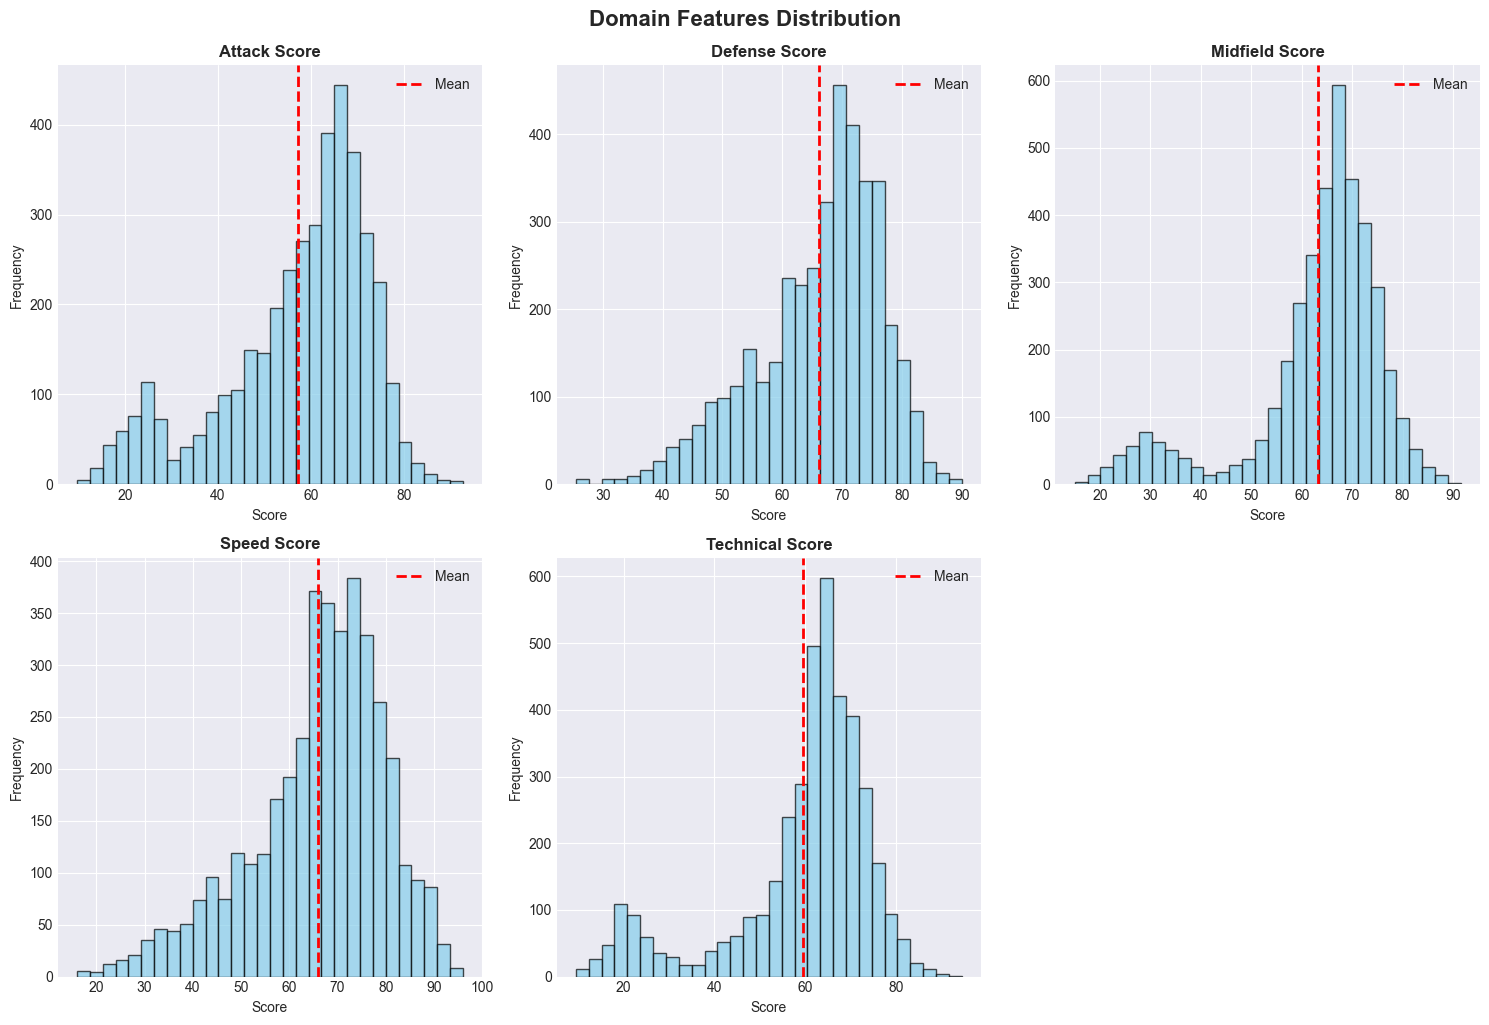

In [7]:
# Visualize domain features distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

domain_cols = ['attack_score', 'defense_score', 'midfield_score', 'speed_score', 'technical_score']

for idx, col in enumerate(domain_cols):
    ax = axes[idx]
    ax.hist(domain_features[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(domain_features[col].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.legend()

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle('Domain Features Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 🏷️ Encode Labels

In [8]:
# Encode position labels
le = LabelEncoder()
y = le.fit_transform(df['primary_position'])

print(f"🏷️  Encoded {len(le.classes_)} position classes")
print(f"\n📋 Position Classes:")
for i, pos in enumerate(le.classes_):
    print(f"   {i}: {pos}")

🏷️  Encoded 15 position classes

📋 Position Classes:
   0: CAM
   1: CB
   2: CDM
   3: CF
   4: CM
   5: GK
   6: LB
   7: LM
   8: LW
   9: LWB
   10: RB
   11: RM
   12: RW
   13: RWB
   14: ST


## ✂️ Split Data

In [9]:
# Train-test split
test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

print(f"✂️  Data split (test_size={test_size})")
print(f"\n📊 Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"📊 Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

✂️  Data split (test_size=0.2)

📊 Train set: 3194 samples (80.0%)
📊 Test set: 799 samples (20.0%)


## ⚖️ Apply SMOTE for Class Balance

In [10]:
print("⚖️  Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

# Apply SMOTE
smote = SMOTE(random_state=random_state)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n✅ SMOTE applied!")
print(f"   Before: {X_train.shape[0]} samples")
print(f"   After: {X_train_balanced.shape[0]} samples")

print("\n⚖️  Class distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

⚖️  Class distribution BEFORE SMOTE:
0     182
1     588
2     258
3      15
4     348
5     326
6     222
7     185
8      71
9      13
10    237
11    198
12     60
13     13
14    478
Name: count, dtype: int64

✅ SMOTE applied!
   Before: 3194 samples
   After: 8820 samples

⚖️  Class distribution AFTER SMOTE:
0     588
1     588
2     588
3     588
4     588
5     588
6     588
7     588
8     588
9     588
10    588
11    588
12    588
13    588
14    588
Name: count, dtype: int64

✅ SMOTE applied!
   Before: 3194 samples
   After: 8820 samples

⚖️  Class distribution AFTER SMOTE:
0     588
1     588
2     588
3     588
4     588
5     588
6     588
7     588
8     588
9     588
10    588
11    588
12    588
13    588
14    588
Name: count, dtype: int64


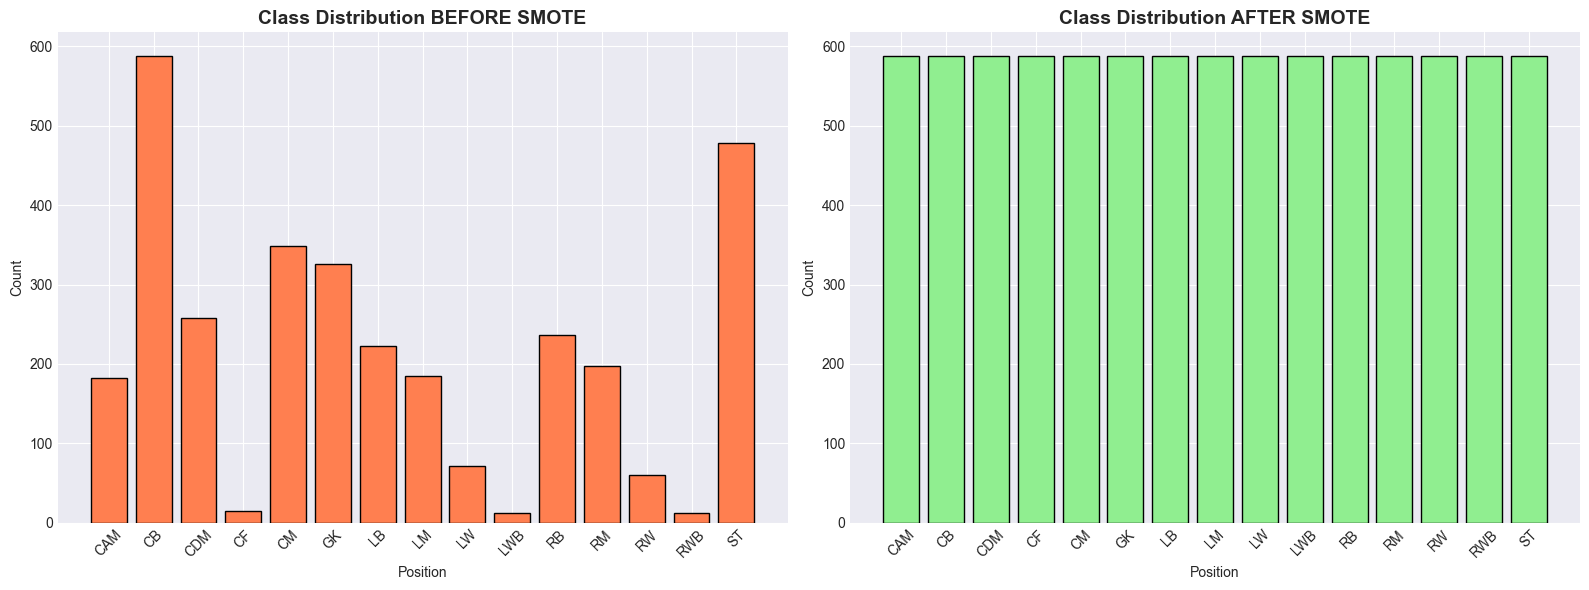

In [11]:
# Visualize class balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before SMOTE
before_counts = pd.Series(y_train).value_counts().sort_index()
before_labels = [le.classes_[i] for i in before_counts.index]
ax1.bar(before_labels, before_counts.values, color='coral', edgecolor='black')
ax1.set_title('Class Distribution BEFORE SMOTE', fontweight='bold', fontsize=14)
ax1.set_xlabel('Position')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# After SMOTE
after_counts = pd.Series(y_train_balanced).value_counts().sort_index()
after_labels = [le.classes_[i] for i in after_counts.index]
ax2.bar(after_labels, after_counts.values, color='lightgreen', edgecolor='black')
ax2.set_title('Class Distribution AFTER SMOTE', fontweight='bold', fontsize=14)
ax2.set_xlabel('Position')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 🌲 Train Random Forest Model

In [12]:
# Model configuration
best_params = {
    'n_estimators': 200,
    'max_depth': 20,
    'min_samples_split': 3,
    'max_features': 'sqrt',
    'random_state': random_state,
    'n_jobs': -1
}

print("🌲 Training Random Forest Classifier...")
print(f"\n⚙️  Parameters:")
for key, value in best_params.items():
    print(f"   - {key}: {value}")

# Train model
model = RandomForestClassifier(**best_params)
model.fit(X_train_balanced, y_train_balanced)

print(f"\n✅ Model trained successfully!")

🌲 Training Random Forest Classifier...

⚙️  Parameters:
   - n_estimators: 200
   - max_depth: 20
   - min_samples_split: 3
   - max_features: sqrt
   - random_state: 42
   - n_jobs: -1

✅ Model trained successfully!

✅ Model trained successfully!


## 📈 Model Evaluation

📊 Model Performance:

   Train Accuracy: 1.0000 (100.00%)
   Test Accuracy:  0.5795 (57.95%)


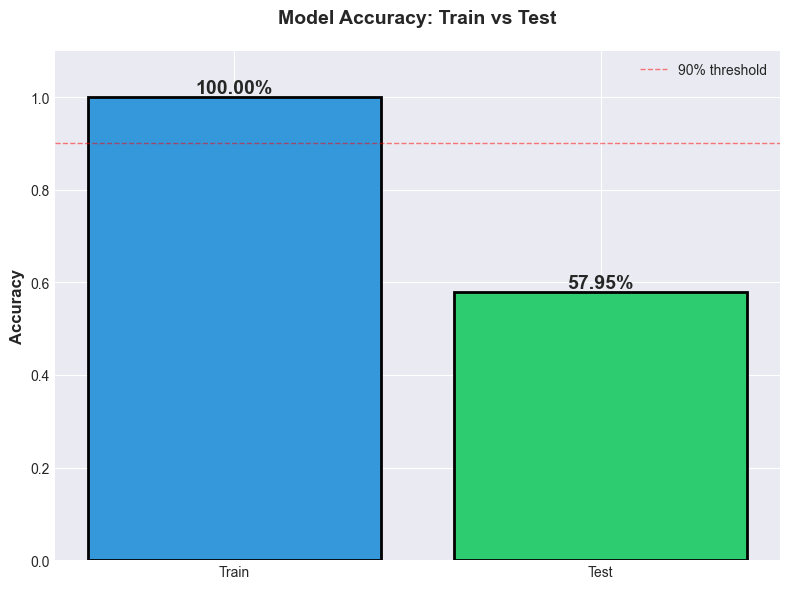

In [13]:
# Predictions
y_train_pred = model.predict(X_train_balanced)
y_test_pred = model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_balanced, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("📊 Model Performance:")
print(f"\n   Train Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Visualize accuracy
fig, ax = plt.subplots(figsize=(8, 6))
scores = [train_accuracy, test_accuracy]
labels = ['Train', 'Test']
colors = ['#3498db', '#2ecc71']

bars = ax.bar(labels, scores, color=colors, edgecolor='black', linewidth=2)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy: Train vs Test', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, 1.1])
ax.axhline(y=0.9, color='red', linestyle='--', linewidth=1, alpha=0.5, label='90% threshold')
ax.legend()
plt.tight_layout()
plt.show()

🔄 Running 5-fold cross-validation...

✅ Cross-validation scores:
   Fold 1: 0.8690 (86.90%)
   Fold 2: 0.8605 (86.05%)
   Fold 3: 0.9235 (92.35%)
   Fold 4: 0.9325 (93.25%)
   Fold 5: 0.9422 (94.22%)

📊 Mean CV Score: 0.9056 (+/- 0.0339)
✅ Cross-validation scores:
   Fold 1: 0.8690 (86.90%)
   Fold 2: 0.8605 (86.05%)
   Fold 3: 0.9235 (92.35%)
   Fold 4: 0.9325 (93.25%)
   Fold 5: 0.9422 (94.22%)

📊 Mean CV Score: 0.9056 (+/- 0.0339)


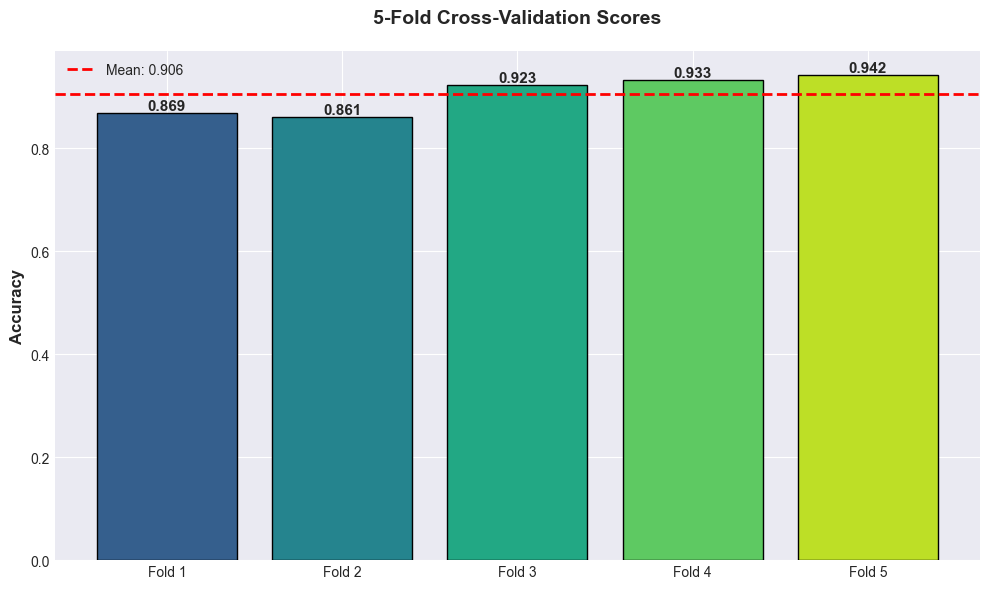

In [14]:
# Cross-validation
print("🔄 Running 5-fold cross-validation...\n")

cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5)

print(f"✅ Cross-validation scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")

print(f"\n📊 Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Visualize CV scores
fig, ax = plt.subplots(figsize=(10, 6))
folds = [f'Fold {i}' for i in range(1, 6)]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(cv_scores)))

bars = ax.bar(folds, cv_scores, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.3f}')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('5-Fold Cross-Validation Scores', fontsize=14, fontweight='bold', pad=20)
ax.legend()
plt.tight_layout()
plt.show()

## 📋 Classification Report

In [15]:
# Classification report
print("📋 Classification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=3))

📋 Classification Report (Test Set):

              precision    recall  f1-score   support

         CAM      0.299     0.444     0.357        45
          CB      0.846     0.857     0.851       147
         CDM      0.426     0.446     0.436        65
          CF      0.000     0.000     0.000         4
          CM      0.544     0.494     0.518        87
          GK      0.988     1.000     0.994        82
          LB      0.404     0.375     0.389        56
          LM      0.211     0.174     0.190        46
          LW      0.062     0.059     0.061        17
         LWB      0.000     0.000     0.000         3
          RB      0.387     0.407     0.397        59
          RM      0.270     0.200     0.230        50
          RW      0.000     0.000     0.000        15
         RWB      0.333     0.333     0.333         3
          ST      0.778     0.817     0.797       120

    accuracy                          0.579       799
   macro avg      0.370     0.374     0.370

## 🔥 Confusion Matrix

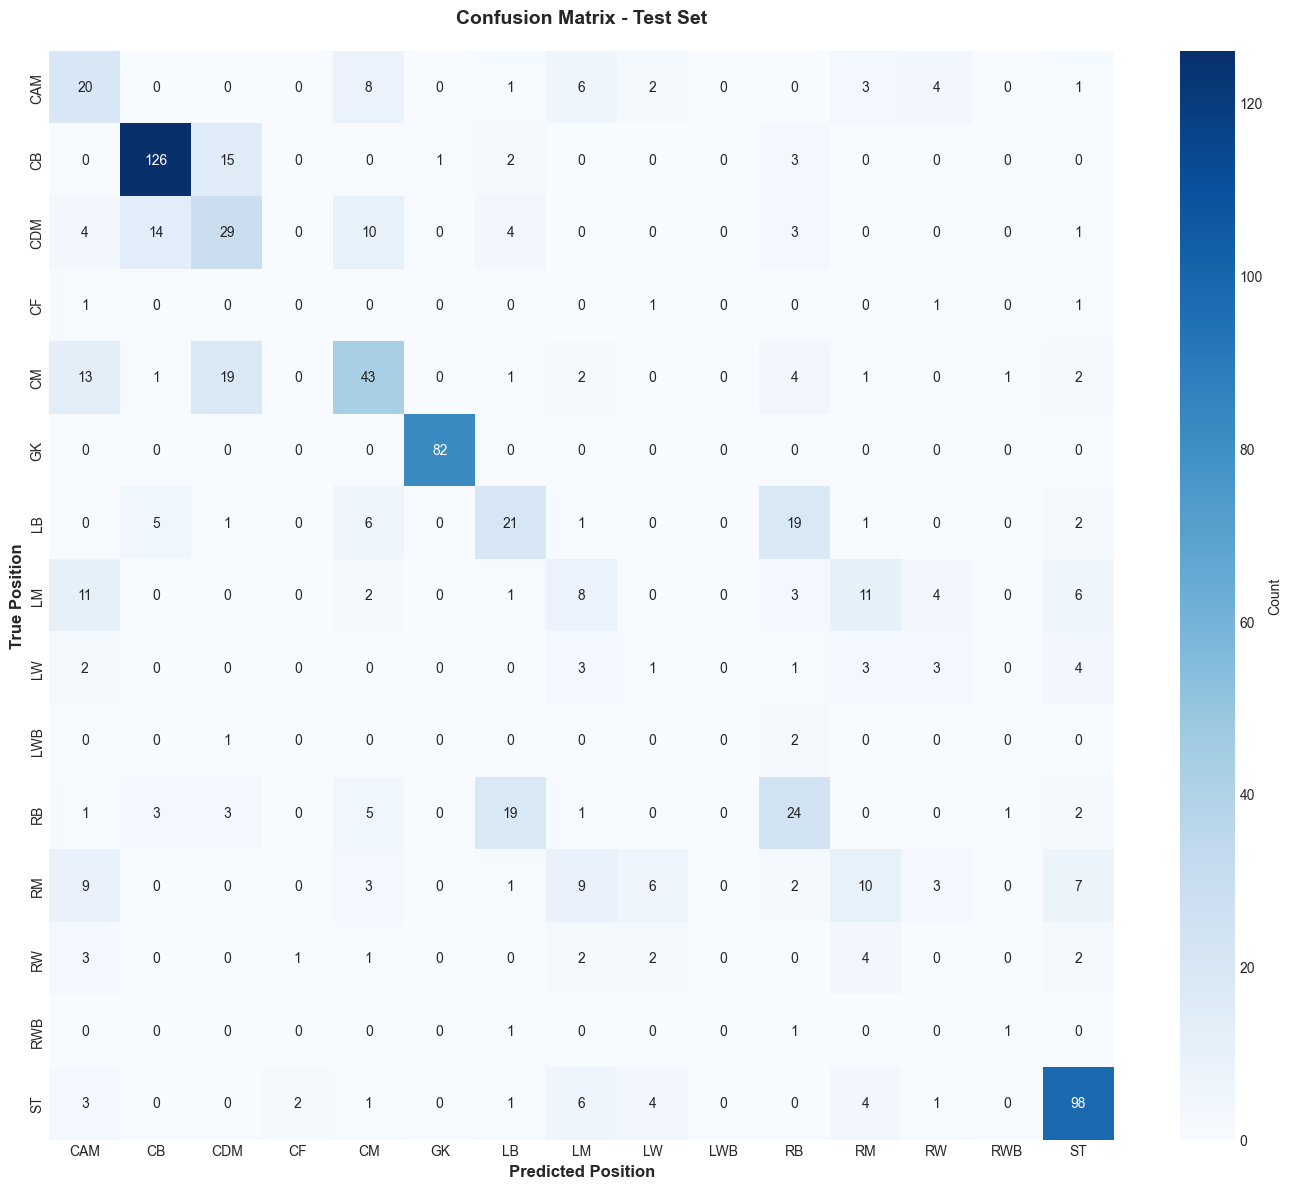

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cbar_kws={'label': 'Count'},
            ax=ax)

ax.set_xlabel('Predicted Position', fontsize=12, fontweight='bold')
ax.set_ylabel('True Position', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## ⭐ Feature Importance

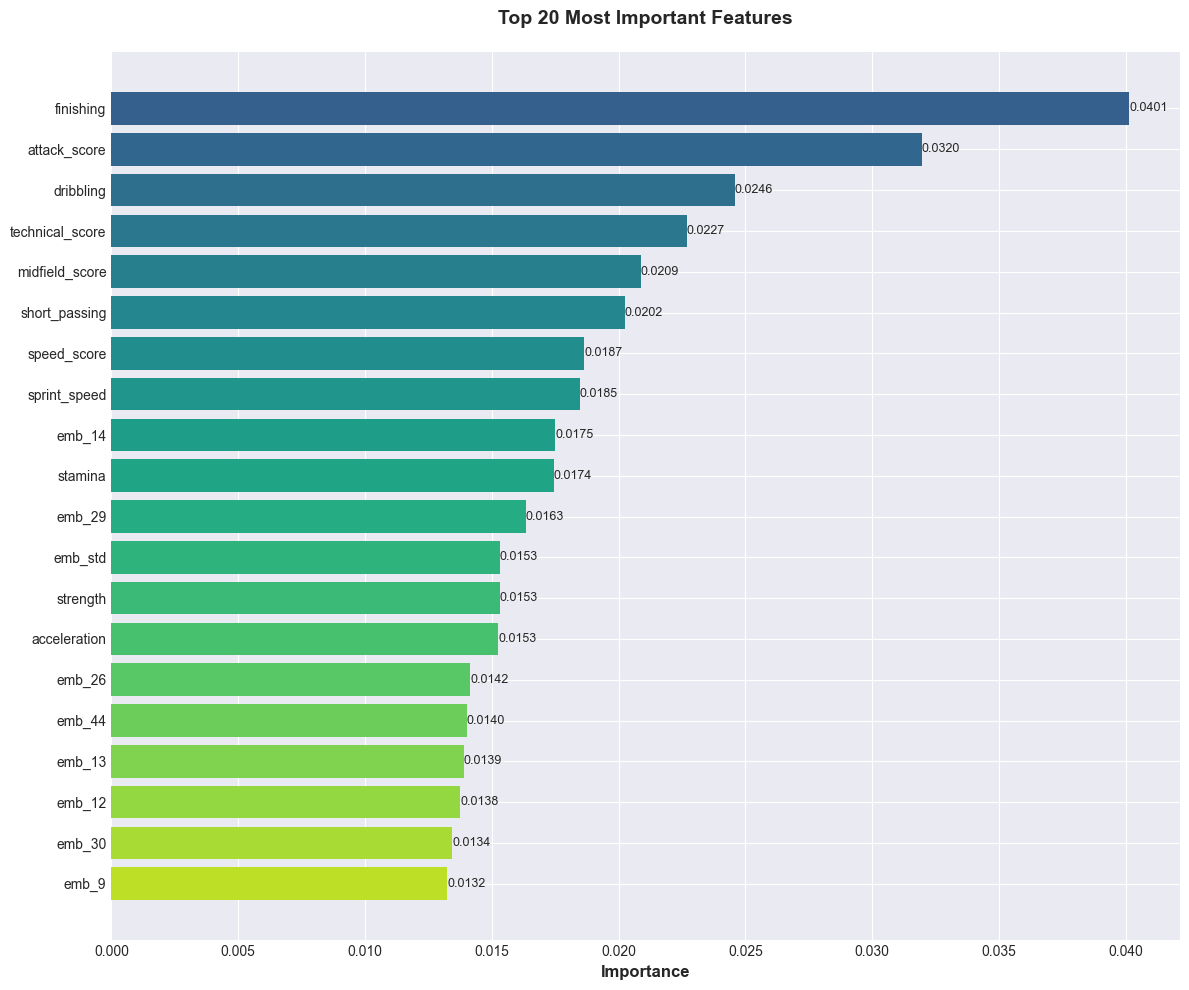


⭐ Top 10 Most Important Features:
   finishing           : 0.0401
   attack_score        : 0.0320
   dribbling           : 0.0246
   technical_score     : 0.0227
   midfield_score      : 0.0209
   short_passing       : 0.0202
   speed_score         : 0.0187
   sprint_speed        : 0.0185
   emb_14              : 0.0175
   stamina             : 0.0174


In [17]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20 features
top_20 = feature_importance.head(20)

fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_20)))
bars = ax.barh(range(len(top_20)), top_20['importance'], color=colors)

ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n⭐ Top 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:20s}: {row['importance']:.4f}")


📊 Feature Importance by Category:
   Embedding           : 0.7364 (73.6%)
   Player Stats        : 0.1572 (15.7%)
   Domain Features     : 0.1064 (10.6%)


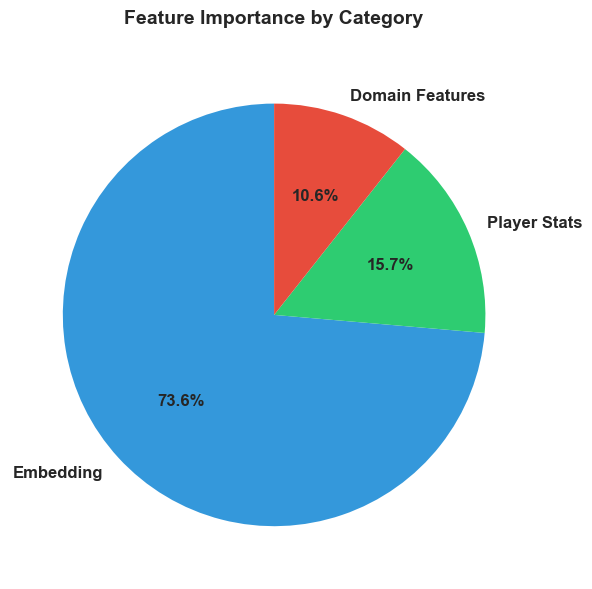

In [18]:
# Feature importance by category
def categorize_feature(feat_name):
    if feat_name.startswith('emb_'):
        return 'Embedding'
    elif feat_name in ['emb_mean', 'emb_std', 'emb_max', 'emb_min', 'emb_range']:
        return 'Embedding Stats'
    elif feat_name in stats_cols:
        return 'Player Stats'
    else:
        return 'Domain Features'

feature_importance['category'] = feature_importance['feature'].apply(categorize_feature)

category_importance = feature_importance.groupby('category')['importance'].sum().sort_values(ascending=False)

print("\n📊 Feature Importance by Category:")
for cat, imp in category_importance.items():
    print(f"   {cat:20s}: {imp:.4f} ({imp/category_importance.sum()*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
wedges, texts, autotexts = ax.pie(
    category_importance.values,
    labels=category_importance.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

ax.set_title('Feature Importance by Category', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 💾 Save Model Artifacts

In [19]:
import os

output_dir = "../model"
os.makedirs(output_dir, exist_ok=True)

print(f"💾 Saving model artifacts to: {output_dir}\n")

# Save model
model_path = f"{output_dir}/best_football_model.pkl"
joblib.dump(model, model_path)
print(f"✅ Model saved: {model_path}")

# Save scaler
scaler_path = f"{output_dir}/scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved: {scaler_path}")

# Save label encoder
le_path = f"{output_dir}/label_encoder.pkl"
joblib.dump(le, le_path)
print(f"✅ Label encoder saved: {le_path}")

# Save config
config = {
    "n_embedding_features": 64,
    "stats_cols": stats_cols,
    "use_smote": True,
    "model_type": "RandomForest",
    "accuracy": float(test_accuracy),
    "train_accuracy": float(train_accuracy),
    "cv_score": float(cv_scores.mean()),
    "best_params": best_params,
    "feature_engineering": {
        "embedding_stats": True,
        "normalized_stats": True,
        "domain_features": True
    },
    "trained_at": datetime.now().isoformat(),
    "total_features": X.shape[1],
    "total_samples": len(df),
    "position_classes": le.classes_.tolist()
}

config_path = f"{output_dir}/model_config.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ Config saved: {config_path}")

print(f"\n✅ All artifacts saved successfully!")

💾 Saving model artifacts to: ../model

✅ Model saved: ../model/best_football_model.pkl
✅ Scaler saved: ../model/scaler.pkl
✅ Label encoder saved: ../model/label_encoder.pkl
✅ Config saved: ../model/model_config.json

✅ All artifacts saved successfully!


## 📊 Final Summary

In [20]:
print("="*70)
print("🎉 MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)

print(f"\n📊 Final Model Performance:")
print(f"   - Train Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   - Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - CV Score:       {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print(f"\n🔧 Model Configuration:")
print(f"   - Algorithm: Random Forest")
print(f"   - Estimators: {best_params['n_estimators']}")
print(f"   - Max Depth: {best_params['max_depth']}")
print(f"   - Total Features: {X.shape[1]}")
print(f"   - Position Classes: {len(le.classes_)}")

print(f"\n📦 Saved Artifacts:")
print(f"   - best_football_model.pkl")
print(f"   - scaler.pkl")
print(f"   - label_encoder.pkl")
print(f"   - model_config.json")

print(f"\n🎯 Next Steps:")
print(f"   - Run: streamlit run app.py")
print(f"   - Or: python step5_predict_and_save.py")

print("\n" + "="*70)

🎉 MODEL TRAINING COMPLETED SUCCESSFULLY!

📊 Final Model Performance:
   - Train Accuracy: 1.0000 (100.00%)
   - Test Accuracy:  0.5795 (57.95%)
   - CV Score:       0.9056 (+/- 0.0339)

🔧 Model Configuration:
   - Algorithm: Random Forest
   - Estimators: 200
   - Max Depth: 20
   - Total Features: 82
   - Position Classes: 15

📦 Saved Artifacts:
   - best_football_model.pkl
   - scaler.pkl
   - label_encoder.pkl
   - model_config.json

🎯 Next Steps:
   - Run: streamlit run app.py
   - Or: python step5_predict_and_save.py

